# Pipeline NLP: Prevendo Sucesso de Jogos a partir do Discurso Pré-Lançamento
### Versão Google Colab — executar com GPU (Runtime → Alterar tipo de runtime → T4 GPU)

Experimentos seguem o stack da disciplina:
1. **Baseline**: TF-IDF + Regressão Logística
2. **DistilBERT (frozen)**: apenas a cabeça de classificação é treinada
3. **DistilBERT (fine-tuned)**: todos os pesos treinados com AdamW (lr=1e-5)

Dois targets: **Avaliação** (`label_rating`) e **Vendas** (`label_sales`).
Métrica principal: **F1-macro**. Meta ≥ 0,70.

## Configuração

1. Configurar runtime para **GPU**: Runtime → Alterar tipo de runtime → GPU T4 → Salvar
2. Executar esta célula para montar o Google Drive
3. Garantir que a pasta `nlp-game-predictor/data/processed/` existe no Drive com os 4 arquivos CSV

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q transformers
print('Setup done.')

Mounted at /content/drive
Setup done.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

from transformers import DistilBertTokenizer, DistilBertModel

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type != 'cuda':
    print('WARNING: GPU not detected. Go to Runtime â†’ Change runtime type â†’ T4 GPU')

Device: cuda


In [3]:
DRIVE_ROOT  = '/content/drive/MyDrive/nlp-game-predictor'
DATA_DIR    = Path(DRIVE_ROOT) / 'data/processed'
REPORTS_DIR = Path(DRIVE_ROOT) / 'reports/figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Verify data files exist
for fname in ['dataset_rating_granular.csv', 'dataset_rating_aggregated.csv',
              'dataset_sales_granular.csv',  'dataset_sales_aggregated.csv']:
    p = DATA_DIR / fname
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  {status}  {fname}')

USE_SUBSET    = False
SUBSET_SIZE   = 1_000

MAX_TFIDF     = 10_000
MAX_LEN       = 128
BATCH_FROZEN  = 64    # larger batches on GPU
BATCH_FINETUNE = 32
N_EPOCHS      = 3
LR            = 1e-5

  OK  dataset_rating_granular.csv
  OK  dataset_rating_aggregated.csv
  OK  dataset_sales_granular.csv
  OK  dataset_sales_aggregated.csv


## 1. Carregamento de dados e análise exploratória

In [4]:
df_rating = pd.read_csv(DATA_DIR / 'dataset_rating_granular.csv')
df_sales  = pd.read_csv(DATA_DIR / 'dataset_sales_granular.csv')
df_sales  = df_sales[df_sales['label_sales'].notna()].copy()

for tag, df, lc in [('Rating', df_rating, 'label_rating'), ('Sales', df_sales, 'label_sales')]:
    print(f'=== {tag} ===  shape={df.shape}')
    print('  Labels :', df[lc].value_counts().to_dict())
    print('  Sources:', df['source'].value_counts().to_dict())
    print(f"  Text len (chars) â€” median: {df['text'].str.len().median():.0f}, max: {df['text'].str.len().max()}")
    print()

=== Rating ===  shape=(5565, 6)
  Labels : {1: 4670, 0: 895}
  Sources: {'youtube': 3250, 'reddit': 2315}
  Text len (chars) â€” median: 73, max: 40123

=== Sales ===  shape=(5396, 6)
  Labels : {1.0: 4879, 0.0: 517}
  Sources: {'youtube': 3250, 'reddit': 2146}
  Text len (chars) â€” median: 72, max: 40123



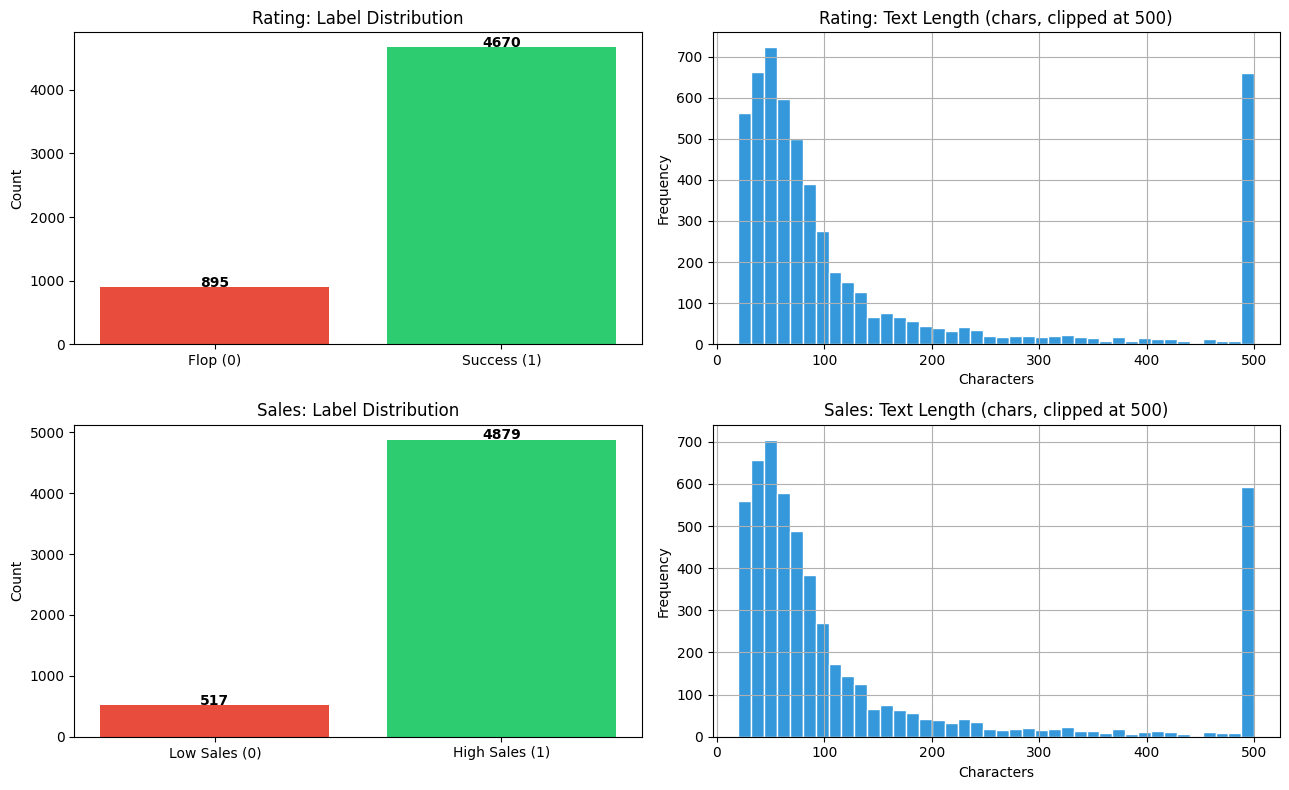

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (tag, df, lc, lab) in enumerate([
    ('Rating', df_rating, 'label_rating', ['Flop (0)', 'Success (1)']),
    ('Sales',  df_sales,  'label_sales',  ['Low Sales (0)', 'High Sales (1)']),
]):
    counts = df[lc].value_counts().sort_index()
    axes[row, 0].bar(lab, counts.values, color=['#e74c3c', '#2ecc71'])
    axes[row, 0].set_title(f'{tag}: Label Distribution')
    axes[row, 0].set_ylabel('Count')
    for i, v in enumerate(counts.values):
        axes[row, 0].text(i, v + 10, str(v), ha='center', fontweight='bold')

    df['text'].str.len().clip(upper=500).hist(ax=axes[row, 1], bins=40, color='#3498db', edgecolor='white')
    axes[row, 1].set_title(f'{tag}: Text Length (chars, clipped at 500)')
    axes[row, 1].set_xlabel('Characters')
    axes[row, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(REPORTS_DIR / '02_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Definições de modelos e utilitários compartilhados

In [6]:
class BertClassifier(nn.Module):
    def __init__(self, num_classes=2, frozen=True):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        if frozen:
            for param in self.bert.parameters():
                param.requires_grad = False
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]  # CLS token -> linear classifier
        return self.classifier(cls)

In [7]:
_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_texts(texts):
    enc = _tokenizer(
        list(texts), max_length=MAX_LEN,
        padding='max_length', truncation=True, return_tensors='pt',
    )
    return enc['input_ids'], enc['attention_mask']


def make_criterion(y_train):
    weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
    return nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float).to(DEVICE))


def run_epoch(model, loader, optimizer, criterion):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, preds, labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for ids, mask, y in loader:
            ids, mask, y = ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            logits = model(ids, mask)
            loss = criterion(logits, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            preds.extend(logits.argmax(1).cpu().tolist())
            labels.extend(y.cpu().tolist())
    return total_loss / len(loader), f1_score(labels, preds, average='macro'), preds


def plot_target_curves(target_name, train_sizes, tr_mean, tr_std, val_mean, val_std,
                       hist_frozen, hist_ft, f1_lr, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_sizes, tr_mean, 'o-', label='Train', color='#2196F3')
    axes[0].fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color='#2196F3')
    axes[0].plot(train_sizes, val_mean, 's--', label='Val (5-fold CV)', color='#FF5722')
    axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#FF5722')
    axes[0].axhline(0.70, ls=':', color='gray', label='Target (0.70)')
    axes[0].set_title(f'{target_name}: TF-IDF + LR Learning Curve')
    axes[0].set_xlabel('Training samples')
    axes[0].set_ylabel('F1-macro')
    axes[0].legend()
    axes[0].set_ylim(0, 1)

    epochs = list(range(1, len(hist_frozen['val_f1']) + 1))
    axes[1].plot(epochs, hist_frozen['val_f1'], 'o-', label='Frozen encoder', color='#9C27B0')
    axes[1].plot(epochs, hist_ft['val_f1'],    's-', label='Fine-tuned',      color='#4CAF50')
    axes[1].axhline(f1_lr, ls=':', color='#FF5722', label=f'LR baseline ({f1_lr:.3f})')
    axes[1].axhline(0.70,  ls=':', color='gray', label='Target (0.70)')
    axes[1].set_title(f'{target_name}: DistilBERT Val F1-macro per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1-macro')
    axes[1].legend()
    axes[1].set_ylim(0, 1)
    axes[1].set_xticks(epochs)

    plt.suptitle(f'Learning Curves â€” {target_name} Target', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## 3. Target de avaliação (`label_rating`)

Prediz se o jogo é bem avaliado (sucesso) ou mal avaliado (fracasso) a partir do texto pré-lançamento.
Distribuição das classes: ~84% sucesso / 16% fracasso — tratada com `class_weight='balanced'` e weighted loss.

In [8]:
df_r = df_rating.copy()
if USE_SUBSET:
    df_r = df_r.sample(SUBSET_SIZE, random_state=SEED)

X_r = df_r['text'].fillna('').values
y_r = df_r['label_rating'].values.astype(int)

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(
    X_r, y_r, test_size=0.2, stratify=y_r, random_state=SEED
)
print(f'Train: {len(X_r_tr)} | Test: {len(X_r_te)}')
print(f'Train labels: {dict(zip(*np.unique(y_r_tr, return_counts=True)))}')
print(f'Test  labels: {dict(zip(*np.unique(y_r_te, return_counts=True)))}')

Train: 4452 | Test: 1113
Train labels: {np.int64(0): np.int64(716), np.int64(1): np.int64(3736)}
Test  labels: {np.int64(0): np.int64(179), np.int64(1): np.int64(934)}


### 3.1 Baseline: TF-IDF + Regressão Logística

In [9]:
pipe_r = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=MAX_TFIDF, ngram_range=(1, 2), sublinear_tf=True, min_df=2,
    )),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED,
    )),
])
pipe_r.fit(X_r_tr, y_r_tr)
y_pred_r_lr = pipe_r.predict(X_r_te)

print('=== Rating: TF-IDF + LR ===')
print(classification_report(y_r_te, y_pred_r_lr, target_names=['Flop', 'Success']))
f1_r_lr = f1_score(y_r_te, y_pred_r_lr, average='macro')
print(f'F1-macro: {f1_r_lr:.4f}')

r_sizes, r_tr_sc, r_val_sc = learning_curve(
    pipe_r, X_r_tr, y_r_tr,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', cv=5, n_jobs=-1,
)
print('Learning curve computed.')

=== Rating: TF-IDF + LR ===
              precision    recall  f1-score   support

        Flop       0.78      0.89      0.83       179
     Success       0.98      0.95      0.97       934

    accuracy                           0.94      1113
   macro avg       0.88      0.92      0.90      1113
weighted avg       0.95      0.94      0.94      1113

F1-macro: 0.8989
Learning curve computed.


### 3.2 DistilBERT (Encoder congelado)

In [10]:
print('Tokenizing rating dataset...')
r_tr_ids, r_tr_mask = tokenize_texts(X_r_tr)
r_te_ids, r_te_mask = tokenize_texts(X_r_te)

r_tr_ds = TensorDataset(r_tr_ids, r_tr_mask, torch.tensor(y_r_tr, dtype=torch.long))
r_te_ds = TensorDataset(r_te_ids, r_te_mask, torch.tensor(y_r_te, dtype=torch.long))
r_crit  = make_criterion(y_r_tr)
print('Done.')

Tokenizing rating dataset...
Done.


In [11]:
model_r_frozen = BertClassifier(frozen=True).to(DEVICE)
opt_r_frozen   = AdamW(model_r_frozen.classifier.parameters(), lr=LR)
dl_r_tr_f = DataLoader(r_tr_ds, batch_size=BATCH_FROZEN,   shuffle=True)
dl_r_te_f = DataLoader(r_te_ds, batch_size=BATCH_FROZEN,   shuffle=False)

hist_r_frozen = {'train_f1': [], 'val_f1': []}
print('Training DistilBERT (frozen) â€” Rating...')
for epoch in range(1, N_EPOCHS + 1):
    _, tr_f1, _ = run_epoch(model_r_frozen, dl_r_tr_f, opt_r_frozen, r_crit)
    _, vl_f1, _ = run_epoch(model_r_frozen, dl_r_te_f, None, r_crit)
    hist_r_frozen['train_f1'].append(tr_f1)
    hist_r_frozen['val_f1'].append(vl_f1)
    print(f'  Epoch {epoch}/{N_EPOCHS}  train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}')

_, _, preds_r_frozen = run_epoch(model_r_frozen, dl_r_te_f, None, r_crit)
print()
print('=== Rating: DistilBERT (Frozen) ===')
print(classification_report(y_r_te, preds_r_frozen, target_names=['Flop', 'Success']))
f1_r_frozen = f1_score(y_r_te, preds_r_frozen, average='macro')
print(f'F1-macro: {f1_r_frozen:.4f}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training DistilBERT (frozen) â€” Rating...
  Epoch 1/3  train_f1=0.5956  val_f1=0.6383
  Epoch 2/3  train_f1=0.6664  val_f1=0.7016
  Epoch 3/3  train_f1=0.6620  val_f1=0.6987

=== Rating: DistilBERT (Frozen) ===
              precision    recall  f1-score   support

        Flop       0.43      0.68      0.52       179
     Success       0.93      0.82      0.87       934

    accuracy                           0.80      1113
   macro avg       0.68      0.75      0.70      1113
weighted avg       0.85      0.80      0.82      1113

F1-macro: 0.6987


### 3.3 DistilBERT (Fine-tuned)

In [12]:
model_r_ft = BertClassifier(frozen=False).to(DEVICE)
opt_r_ft   = AdamW(model_r_ft.parameters(), lr=LR)
dl_r_tr_ft = DataLoader(r_tr_ds, batch_size=BATCH_FINETUNE, shuffle=True)
dl_r_te_ft = DataLoader(r_te_ds, batch_size=BATCH_FINETUNE, shuffle=False)

hist_r_ft = {'train_f1': [], 'val_f1': []}
print('Training DistilBERT (fine-tuned) â€” Rating...')
for epoch in range(1, N_EPOCHS + 1):
    _, tr_f1, _ = run_epoch(model_r_ft, dl_r_tr_ft, opt_r_ft, r_crit)
    _, vl_f1, _ = run_epoch(model_r_ft, dl_r_te_ft, None, r_crit)
    hist_r_ft['train_f1'].append(tr_f1)
    hist_r_ft['val_f1'].append(vl_f1)
    print(f'  Epoch {epoch}/{N_EPOCHS}  train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}')

_, _, preds_r_ft = run_epoch(model_r_ft, dl_r_te_ft, None, r_crit)
print()
print('=== Rating: DistilBERT (Fine-tuned) ===')
print(classification_report(y_r_te, preds_r_ft, target_names=['Flop', 'Success']))
f1_r_ft = f1_score(y_r_te, preds_r_ft, average='macro')
print(f'F1-macro: {f1_r_ft:.4f}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training DistilBERT (fine-tuned) â€” Rating...
  Epoch 1/3  train_f1=0.7125  val_f1=0.8334
  Epoch 2/3  train_f1=0.8684  val_f1=0.8752
  Epoch 3/3  train_f1=0.9126  val_f1=0.8801

=== Rating: DistilBERT (Fine-tuned) ===
              precision    recall  f1-score   support

        Flop       0.70      0.95      0.81       179
     Success       0.99      0.92      0.95       934

    accuracy                           0.93      1113
   macro avg       0.84      0.94      0.88      1113
weighted avg       0.94      0.93      0.93      1113

F1-macro: 0.8801


### 3.4 Resumo dos resultados — avaliação

Rating target results:
                  Model  F1-macro
 TF-IDF + LR (baseline)    0.8989
    DistilBERT (frozen)    0.6987
DistilBERT (fine-tuned)    0.8801


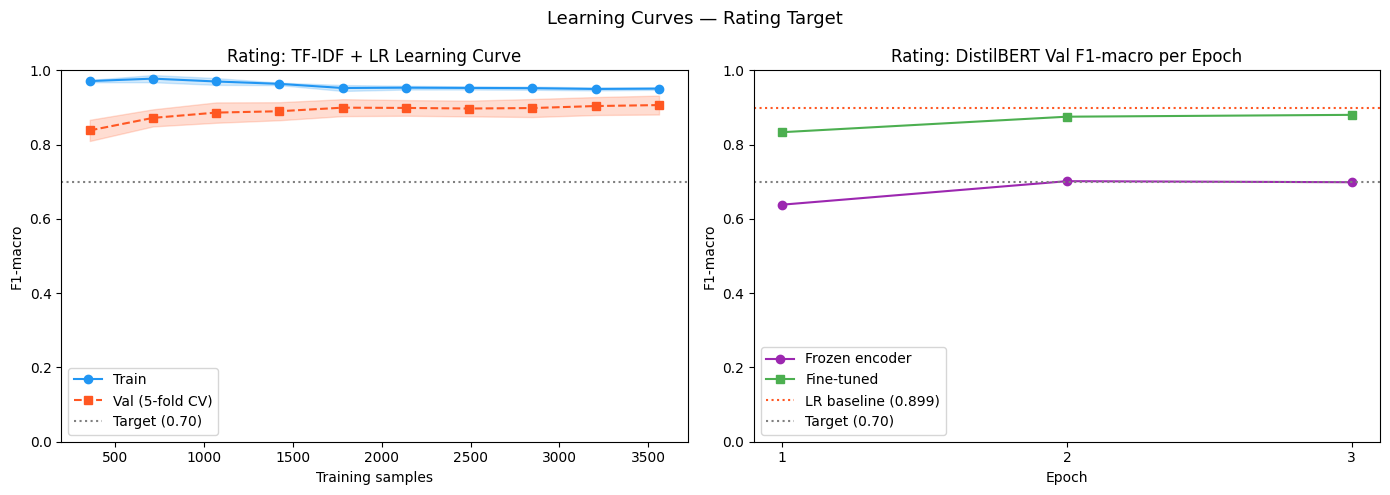

Saved: /content/drive/MyDrive/nlp-game-predictor/reports/figures/02_learning_curves_rating.png


In [13]:
results_rating = pd.DataFrame([
    {'Model': 'TF-IDF + LR (baseline)', 'F1-macro': round(f1_r_lr, 4)},
    {'Model': 'DistilBERT (frozen)',     'F1-macro': round(f1_r_frozen, 4)},
    {'Model': 'DistilBERT (fine-tuned)', 'F1-macro': round(f1_r_ft, 4)},
])
print('Rating target results:')
print(results_rating.to_string(index=False))

plot_target_curves(
    'Rating',
    r_sizes,
    r_tr_sc.mean(axis=1), r_tr_sc.std(axis=1),
    r_val_sc.mean(axis=1), r_val_sc.std(axis=1),
    hist_r_frozen, hist_r_ft, f1_r_lr,
    REPORTS_DIR / '02_learning_curves_rating.png',
)

del model_r_frozen, model_r_ft
torch.cuda.empty_cache()

## 4. Target de vendas (`label_sales`)

Prediz se um jogo pago atinge vendas altas (≥ 150k donos estimados) ou baixas.
Jogos gratuitos (`price == 0`) excluídos deste dataset.

In [14]:
df_s = df_sales.copy()
if USE_SUBSET:
    df_s = df_s.sample(min(SUBSET_SIZE, len(df_s)), random_state=SEED)

X_s = df_s['text'].fillna('').values
y_s = df_s['label_sales'].values.astype(int)

X_s_tr, X_s_te, y_s_tr, y_s_te = train_test_split(
    X_s, y_s, test_size=0.2, stratify=y_s, random_state=SEED
)
print(f'Train: {len(X_s_tr)} | Test: {len(X_s_te)}')
print(f'Train labels: {dict(zip(*np.unique(y_s_tr, return_counts=True)))}')
print(f'Test  labels: {dict(zip(*np.unique(y_s_te, return_counts=True)))}')

Train: 4316 | Test: 1080
Train labels: {np.int64(0): np.int64(414), np.int64(1): np.int64(3902)}
Test  labels: {np.int64(0): np.int64(103), np.int64(1): np.int64(977)}


### 4.1 Baseline: TF-IDF + Regressão Logística

In [15]:
pipe_s = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=MAX_TFIDF, ngram_range=(1, 2), sublinear_tf=True, min_df=2,
    )),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED,
    )),
])
pipe_s.fit(X_s_tr, y_s_tr)
y_pred_s_lr = pipe_s.predict(X_s_te)

print('=== Sales: TF-IDF + LR ===')
print(classification_report(y_s_te, y_pred_s_lr, target_names=['Low Sales', 'High Sales']))
f1_s_lr = f1_score(y_s_te, y_pred_s_lr, average='macro')
print(f'F1-macro: {f1_s_lr:.4f}')

s_sizes, s_tr_sc, s_val_sc = learning_curve(
    pipe_s, X_s_tr, y_s_tr,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', cv=5, n_jobs=-1,
)
print('Learning curve computed.')

=== Sales: TF-IDF + LR ===
              precision    recall  f1-score   support

   Low Sales       0.44      0.62      0.52       103
  High Sales       0.96      0.92      0.94       977

    accuracy                           0.89      1080
   macro avg       0.70      0.77      0.73      1080
weighted avg       0.91      0.89      0.90      1080

F1-macro: 0.7280
Learning curve computed.


### 4.2 DistilBERT (Encoder congelado)

In [16]:
print('Tokenizing sales dataset...')
s_tr_ids, s_tr_mask = tokenize_texts(X_s_tr)
s_te_ids, s_te_mask = tokenize_texts(X_s_te)

s_tr_ds = TensorDataset(s_tr_ids, s_tr_mask, torch.tensor(y_s_tr, dtype=torch.long))
s_te_ds = TensorDataset(s_te_ids, s_te_mask, torch.tensor(y_s_te, dtype=torch.long))
s_crit  = make_criterion(y_s_tr)
print('Done.')

Tokenizing sales dataset...
Done.


In [17]:
model_s_frozen = BertClassifier(frozen=True).to(DEVICE)
opt_s_frozen   = AdamW(model_s_frozen.classifier.parameters(), lr=LR)
dl_s_tr_f = DataLoader(s_tr_ds, batch_size=BATCH_FROZEN,   shuffle=True)
dl_s_te_f = DataLoader(s_te_ds, batch_size=BATCH_FROZEN,   shuffle=False)

hist_s_frozen = {'train_f1': [], 'val_f1': []}
print('Training DistilBERT (frozen) â€” Sales...')
for epoch in range(1, N_EPOCHS + 1):
    _, tr_f1, _ = run_epoch(model_s_frozen, dl_s_tr_f, opt_s_frozen, s_crit)
    _, vl_f1, _ = run_epoch(model_s_frozen, dl_s_te_f, None, s_crit)
    hist_s_frozen['train_f1'].append(tr_f1)
    hist_s_frozen['val_f1'].append(vl_f1)
    print(f'  Epoch {epoch}/{N_EPOCHS}  train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}')

_, _, preds_s_frozen = run_epoch(model_s_frozen, dl_s_te_f, None, s_crit)
print()
print('=== Sales: DistilBERT (Frozen) ===')
print(classification_report(y_s_te, preds_s_frozen, target_names=['Low Sales', 'High Sales']))
f1_s_frozen = f1_score(y_s_te, preds_s_frozen, average='macro')
print(f'F1-macro: {f1_s_frozen:.4f}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training DistilBERT (frozen) â€” Sales...
  Epoch 1/3  train_f1=0.4788  val_f1=0.4783
  Epoch 2/3  train_f1=0.4845  val_f1=0.4848
  Epoch 3/3  train_f1=0.4863  val_f1=0.4822

=== Sales: DistilBERT (Frozen) ===
              precision    recall  f1-score   support

   Low Sales       0.11      0.32      0.16       103
  High Sales       0.91      0.72      0.80       977

    accuracy                           0.68      1080
   macro avg       0.51      0.52      0.48      1080
weighted avg       0.83      0.68      0.74      1080

F1-macro: 0.4822


### 4.3 DistilBERT (Fine-tuned)

In [18]:
model_s_ft = BertClassifier(frozen=False).to(DEVICE)
opt_s_ft   = AdamW(model_s_ft.parameters(), lr=LR)
dl_s_tr_ft = DataLoader(s_tr_ds, batch_size=BATCH_FINETUNE, shuffle=True)
dl_s_te_ft = DataLoader(s_te_ds, batch_size=BATCH_FINETUNE, shuffle=False)

hist_s_ft = {'train_f1': [], 'val_f1': []}
print('Training DistilBERT (fine-tuned) â€” Sales...')
for epoch in range(1, N_EPOCHS + 1):
    _, tr_f1, _ = run_epoch(model_s_ft, dl_s_tr_ft, opt_s_ft, s_crit)
    _, vl_f1, _ = run_epoch(model_s_ft, dl_s_te_ft, None, s_crit)
    hist_s_ft['train_f1'].append(tr_f1)
    hist_s_ft['val_f1'].append(vl_f1)
    print(f'  Epoch {epoch}/{N_EPOCHS}  train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}')

_, _, preds_s_ft = run_epoch(model_s_ft, dl_s_te_ft, None, s_crit)
print()
print('=== Sales: DistilBERT (Fine-tuned) ===')
print(classification_report(y_s_te, preds_s_ft, target_names=['Low Sales', 'High Sales']))
f1_s_ft = f1_score(y_s_te, preds_s_ft, average='macro')
print(f'F1-macro: {f1_s_ft:.4f}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training DistilBERT (fine-tuned) â€” Sales...
  Epoch 1/3  train_f1=0.5454  val_f1=0.5649
  Epoch 2/3  train_f1=0.6632  val_f1=0.6322
  Epoch 3/3  train_f1=0.7638  val_f1=0.6850

=== Sales: DistilBERT (Fine-tuned) ===
              precision    recall  f1-score   support

   Low Sales       0.35      0.68      0.46       103
  High Sales       0.96      0.86      0.91       977

    accuracy                           0.85      1080
   macro avg       0.65      0.77      0.69      1080
weighted avg       0.90      0.85      0.87      1080

F1-macro: 0.6850


### 4.4 Resumo dos resultados — vendas

Sales target results:
                  Model  F1-macro
 TF-IDF + LR (baseline)    0.7280
    DistilBERT (frozen)    0.4822
DistilBERT (fine-tuned)    0.6850


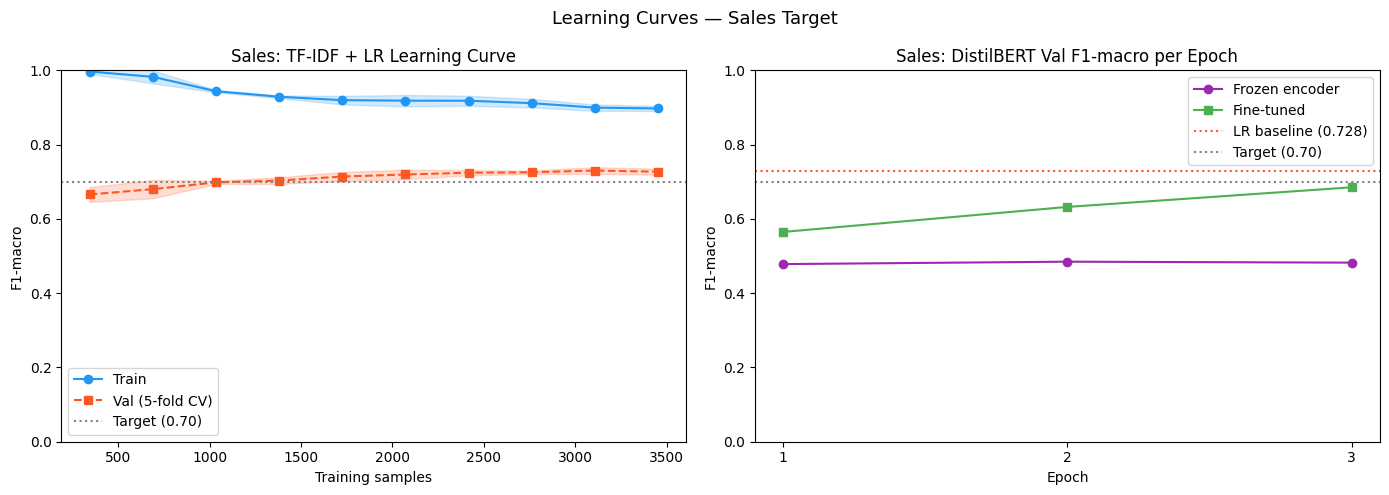

Saved: /content/drive/MyDrive/nlp-game-predictor/reports/figures/02_learning_curves_sales.png


In [19]:
results_sales = pd.DataFrame([
    {'Model': 'TF-IDF + LR (baseline)', 'F1-macro': round(f1_s_lr, 4)},
    {'Model': 'DistilBERT (frozen)',     'F1-macro': round(f1_s_frozen, 4)},
    {'Model': 'DistilBERT (fine-tuned)', 'F1-macro': round(f1_s_ft, 4)},
])
print('Sales target results:')
print(results_sales.to_string(index=False))

plot_target_curves(
    'Sales',
    s_sizes,
    s_tr_sc.mean(axis=1), s_tr_sc.std(axis=1),
    s_val_sc.mean(axis=1), s_val_sc.std(axis=1),
    hist_s_frozen, hist_s_ft, f1_s_lr,
    REPORTS_DIR / '02_learning_curves_sales.png',
)

del model_s_frozen, model_s_ft
torch.cuda.empty_cache()

## 5. Resultados combinados para os dois targets

In [20]:
combined = pd.DataFrame([
    {'Target': 'Rating', 'Model': 'TF-IDF + LR (baseline)', 'F1-macro': round(f1_r_lr, 4)},
    {'Target': 'Rating', 'Model': 'DistilBERT (frozen)',     'F1-macro': round(f1_r_frozen, 4)},
    {'Target': 'Rating', 'Model': 'DistilBERT (fine-tuned)', 'F1-macro': round(f1_r_ft, 4)},
    {'Target': 'Sales',  'Model': 'TF-IDF + LR (baseline)', 'F1-macro': round(f1_s_lr, 4)},
    {'Target': 'Sales',  'Model': 'DistilBERT (frozen)',     'F1-macro': round(f1_s_frozen, 4)},
    {'Target': 'Sales',  'Model': 'DistilBERT (fine-tuned)', 'F1-macro': round(f1_s_ft, 4)},
])
print(combined.to_string(index=False))

Target                   Model  F1-macro
Rating  TF-IDF + LR (baseline)    0.8989
Rating     DistilBERT (frozen)    0.6987
Rating DistilBERT (fine-tuned)    0.8801
 Sales  TF-IDF + LR (baseline)    0.7280
 Sales     DistilBERT (frozen)    0.4822
 Sales DistilBERT (fine-tuned)    0.6850


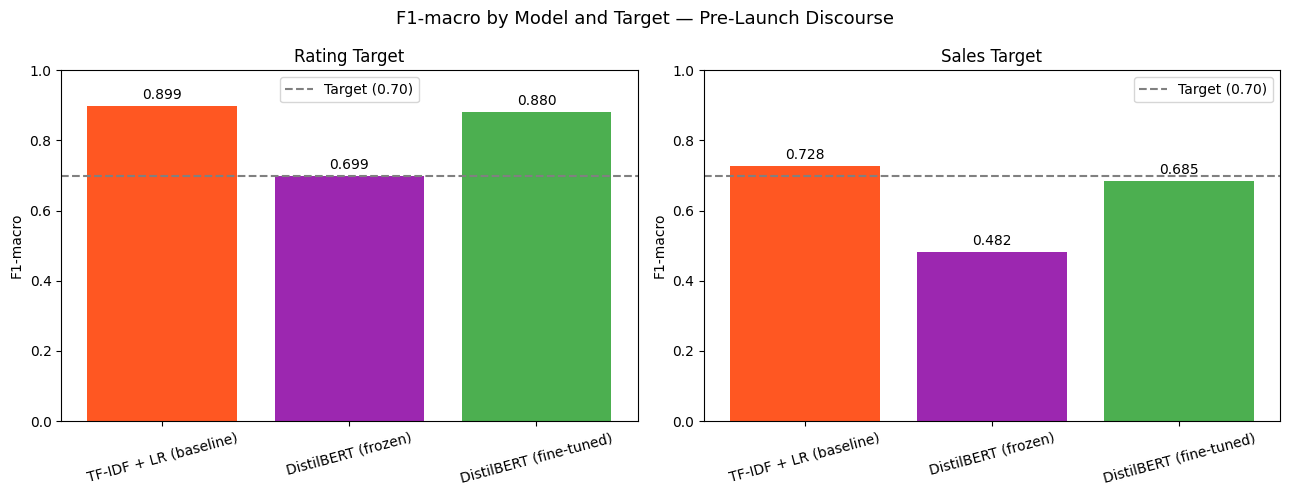

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#FF5722', '#9C27B0', '#4CAF50']

for ax, (target, grp) in zip(axes, combined.groupby('Target')):
    bars = ax.bar(grp['Model'], grp['F1-macro'], color=colors)
    ax.axhline(0.70, ls='--', color='gray', label='Target (0.70)')
    ax.set_title(f'{target} Target')
    ax.set_ylabel('F1-macro')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, grp['F1-macro']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10)
    ax.legend()

plt.suptitle('F1-macro by Model and Target â€” Pre-Launch Discourse', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / '02_results_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Limitações e discussão

### Dados
- **Lacunas de cobertura**: 54/152 arquivos Reddit e 113/145 YouTube estão vazios, principalmente títulos indie com pouca presença online. Jogos sem texto pré-lançamento são excluídos, introduzindo viés em favor de títulos com verba de marketing.
- **Desbalanceamento de classes (avaliação)**: ~84% sucesso / 16% fracasso no dataset granular — tratado com `class_weight='balanced'` e `CrossEntropyLoss` ponderada.
- **Target é snapshot pós-lançamento**: `estimated_owners` e contagens de reviews são valores atuais do dataset HF, não medições ~30 dias após o lançamento. Limitação documentada.
- **`release_date` = data de listagem na Steam**, não data de primeiro lançamento. Verificado para outliers relevantes (ex.: Titanfall 2).

### Metodologia
- **Sem validação temporal**: a divisão treino/teste é aleatória, não cronológica. Uma divisão baseada em tempo simularia melhor o deployment real.
- **Apenas inglês**: textos em outros idiomas filtrados via `langdetect`, descartando sinal de comunidades não-anglófonas.
- **Esparsidade do YouTube**: apenas ~22% dos jogos têm dados de comentários do YouTube; o Reddit é a fonte de sinal dominante.

### Unicidade em relação à literatura
Predição por discurso pré-lançamento em jogos é pouco explorada em comparação com filmes e música. Este trabalho contribui:
1. Avaliação dupla de targets (avaliação + vendas) no mesmo corpus
2. Combinação de posts do Reddit e comentários de trailers do YouTube
3. Janela estrita de 90 dias pré-lançamento — sem data leakage de reviews pós-lançamento